In [51]:
import seaborn as sns
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# Part 1 - Basic Data Analysis

### a)

In [52]:
iris=pd.read_csv("Iris.csv")
print(f"There are {len(iris["SepalLengthCm"])} samples.")

There are 150 samples.


### b)

In [53]:
print(f"There are {len(iris.columns)} attributes:", ", ".join([name for name in iris.columns]))

There are 6 attributes: Id, SepalLengthCm, SepalWidthCm, PetalLengthCm, PetalWidthCm, Species


### c)

In [54]:
for attr in iris.columns:
    if (attr == "Id" or attr == "Species"): continue

    print(attr)
    print("-------------------")
    print(f"Avg: {round(np.mean(iris[attr]), 3)}")
    print(f"Median: {np.median(iris[attr])}")
    print(f"Min: {min(iris[attr])}, Max: {max(iris[attr])}")
    print(f"Std deviation: {round(np.std(iris[attr]),3)}")
    print()

SepalLengthCm
-------------------
Avg: 5.843
Median: 5.8
Min: 4.3, Max: 7.9
Std deviation: 0.825

SepalWidthCm
-------------------
Avg: 3.054
Median: 3.0
Min: 2.0, Max: 4.4
Std deviation: 0.432

PetalLengthCm
-------------------
Avg: 3.759
Median: 4.35
Min: 1.0, Max: 6.9
Std deviation: 1.759

PetalWidthCm
-------------------
Avg: 1.199
Median: 1.3
Min: 0.1, Max: 2.5
Std deviation: 0.761



### d)

In [55]:
unique_names = set(iris["Species"])
print("All possible output names: ",", ".join(unique_names))

All possible output names:  Iris-versicolor, Iris-virginica, Iris-setosa


# Part 2 - Plotting

### a)

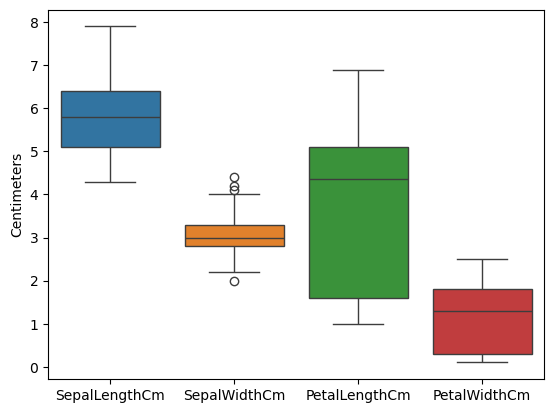

In [56]:
iris_no_id = iris.drop("Id", axis=1)
plt.ylabel("Centimeters")
sns.boxplot(iris_no_id)
plt.show()

We see that PetalLengthCM has the most spread of all the attributes. We see this because it's Q1-Q3 range is the longest, and it's minimum is far away from Q1 and maximum away from Q3.
We see that the attribute with the smallest variance is SepalWidthCm as it's Q1-Q3 range is very short, showing that it's values are tightly packed together.

### b)

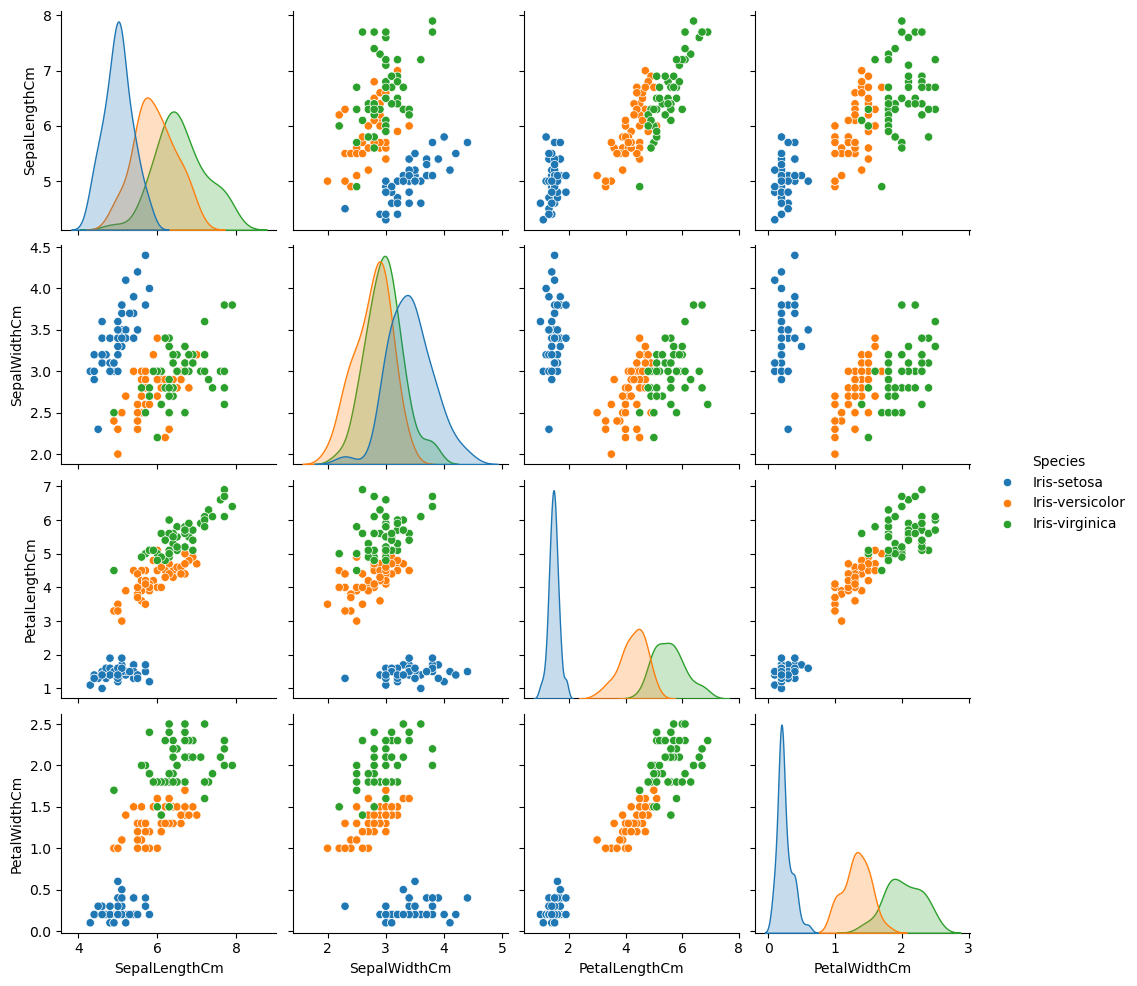

In [57]:
iris_no_id = iris.drop("Id", axis=1)
sns.pairplot(iris_no_id, hue="Species")

Looking at the KDE plots on the diagonal we see that the variance of the attributes does depend on the species, although less so for SepalLengthCm and SepalWidthCm. It is most obvious when looking at PetalLengthCm and PetalWidthCm where iris-setosa stands out with it's peak very far from the others and it being much narrower and not overlapping with the others. THe lack of overlap shows shows that each species is different from another and therefore the variance of all of them taken together will be high even though the individual species may not have a very high variance within them.


### c)

Max PetalLengthCm for the Iris-Setosa:  1.9
Min PetalLengthCm for the Iris-versicolor and Iris-virginica: 3.0, 4.5
Rule: If PetalLengthCm < 2, class = Iris-setosa, otherwise class != Iris-setosa


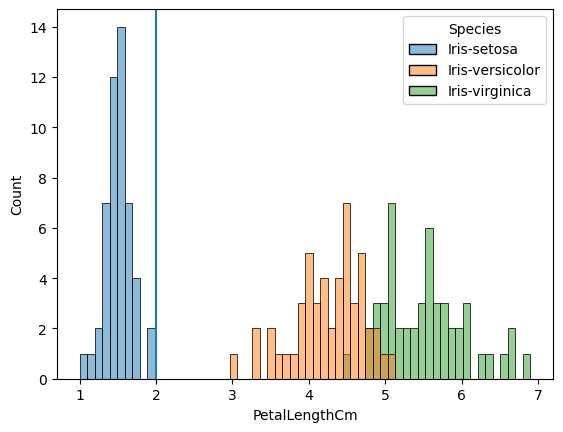

In [58]:
# Seeing where cutoff point should be
a = iris_no_id[iris_no_id["Species"] == "Iris-setosa"]
b = iris_no_id[iris_no_id["Species"] == "Iris-versicolor"]
c = iris_no_id[iris_no_id["Species"] == "Iris-virginica"]

print("Max PetalLengthCm for the Iris-Setosa: ",max(a["PetalLengthCm"]))
print("Min PetalLengthCm for the Iris-versicolor and Iris-virginica: "+ str(min(b["PetalLengthCm"])) + ", " + str(min(c["PetalLengthCm"])))

# Rule:
print("Rule: If PetalLengthCm < 2, class = Iris-setosa, otherwise class != Iris-setosa")

sns.histplot( data=iris, x="PetalLengthCm", hue="Species", bins=60)
plt.axvline(x=2)
plt.show()

# Part 3 - The Titanic

### 3a.1, The effects of the 'Women and children first policy' on survival rate

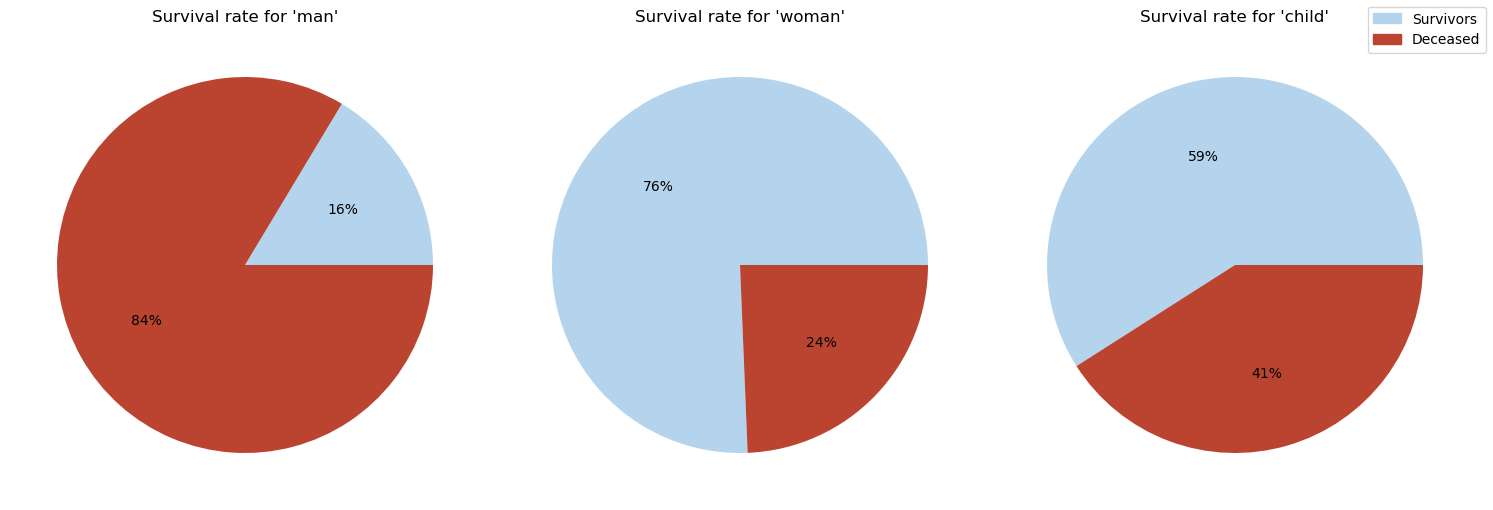

In [59]:
titanic = pd.read_csv('titanic.csv')
colors = ['#B4D4EE','#BB4430']
who_types = titanic["who"].unique()

counts_per_who:list[list[int,int]]
counts_per_who = []

for man_woman_child in who_types:
    survivors = len(titanic[(titanic["who"] == man_woman_child) & (titanic["survived"] == 1)])
    deceased = len(titanic[(titanic["who"] == man_woman_child) & (titanic["survived"] == 0)])
    counts = [survivors, deceased]
    counts_per_who.append(counts)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for i in range(len(who_types)):
    axes[i].pie(counts_per_who[i], colors=colors, autopct='%.0f%%')
    axes[i].set_title(f"Survival rate for '{who_types[i]}'")

survivor_patch = mpatches.Patch(color=colors[0], label="Survivors")
deceased_patch = mpatches.Patch(color=colors[1], label="Deceased")
fig.legend(handles=[survivor_patch, deceased_patch])  

plt.tight_layout()
plt.show()

Looking at survival rates, it is clear that women and children have a much higher survival rate when compared to men (76% and 59% for women and children, versus only 16% for men).

This is strong evidence that the effect of the 'women and children first' policy was such that many more women and children survived the incident.
However, we cannot say for sure that this is due to the policy. For example, men might have partaken in more dangerous activities on the cruise, which would've driven up their death rate. But surely that cannot explain such a large gap in death rate, so the policy most likely had a substanstial impact.



### 3a.2 - Class breakdowns

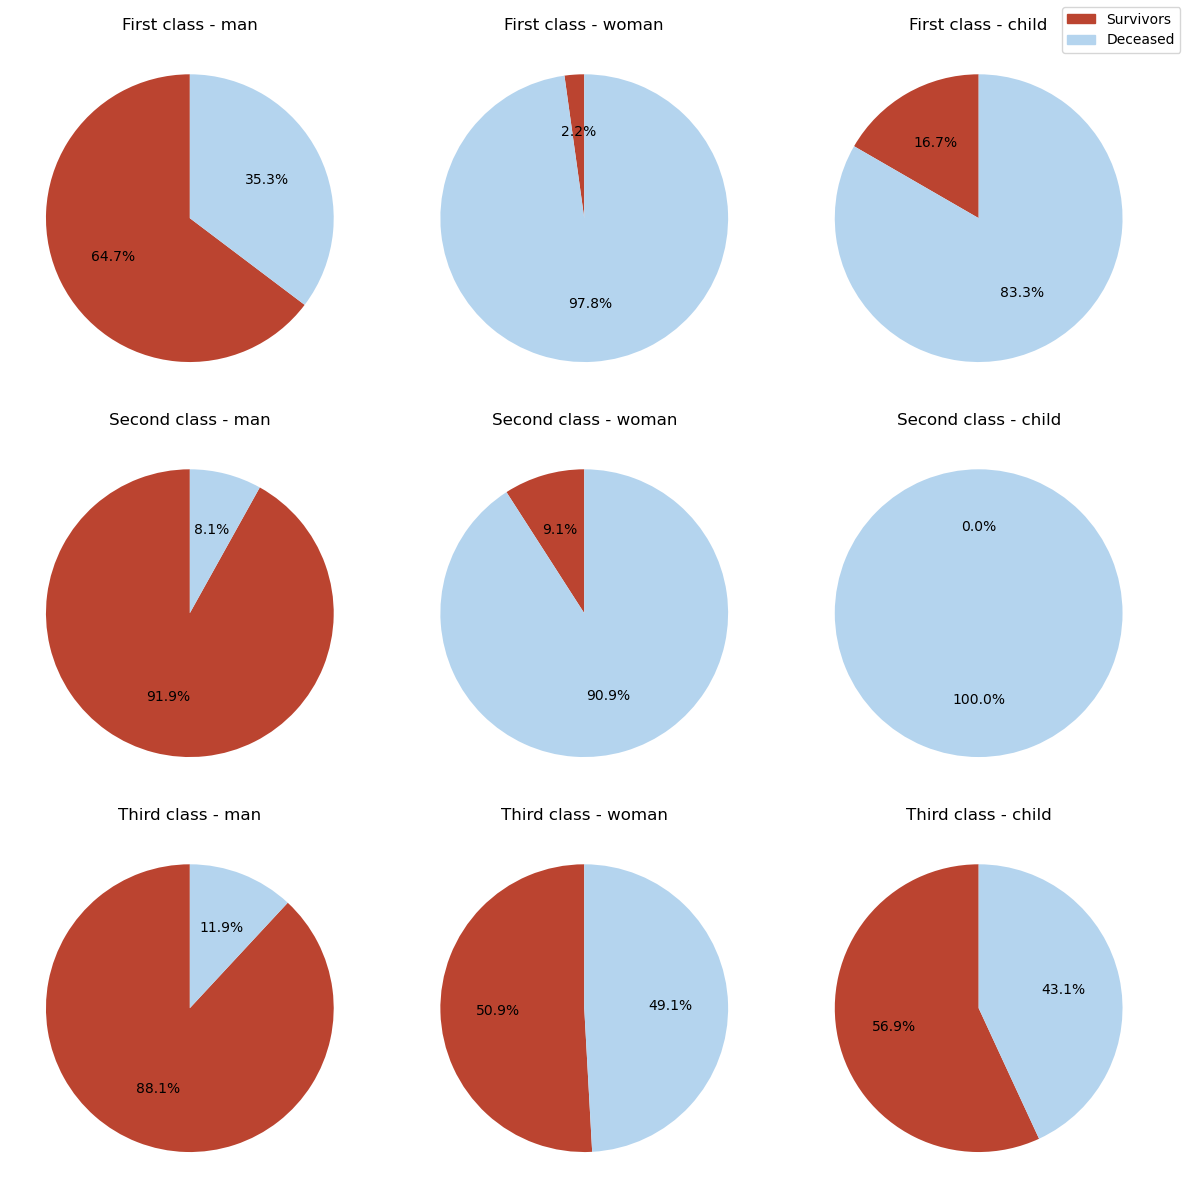

In [60]:
classes = ["First", "Second", "Third"]
who_types = titanic["who"].unique()
colors = ['#BB4430','#B4D4EE']

fig, axes = plt.subplots(len(classes), len(who_types), figsize=(12, 12))

for i, class_ in enumerate(classes):
    for j, who in enumerate(who_types):
        ax = axes[i, j]
        subset = titanic[(titanic["class"] == class_) & (titanic["who"] == who)]
        counts = subset["survived"].value_counts().reindex([0, 1], fill_value=0)
        ax.pie(
            counts,
            colors=colors,
            autopct="%1.1f%%",
            startangle=90
        )
        ax.set_title(f"{class_} class - {who}")


survivor_patch = mpatches.Patch(color=colors[0], label="Survivors")
deceased_patch = mpatches.Patch(color=colors[1], label="Deceased")
fig.legend(handles=[survivor_patch, deceased_patch])  

plt.tight_layout()
plt.show()

Here we see a series of pie charts breaking down the survival rates of Titanic passengers by class and gender/age group. Each row represents a passenger class (first, second, third), and each column represents a passenger type: man, woman, or child. The red portion of each pie chart represents survivors, while the blue portion represents deceased passengers.

We can see a clear 'L' shape where the survival rate is much lower; this 'L' includes men and passengers in third class. The lower survival rate for men is visible across all classes, emphasising the effect of the policy.
We can also see that third-class passengers generally have lower survival rates (although it is slightly higher for 3rd class men than those in 2nd). From this we can deduce that the "women and children first" policy is very much in effect but it also seems that those in higher classes may have had an easier time getting on lifeboats.


### 3b - Interesting Notes

### Note 1: The economics of towns.

We felt like looking at the different embarkment towns and what we could say about them could be interesting. Let's start by looking at survival rate.

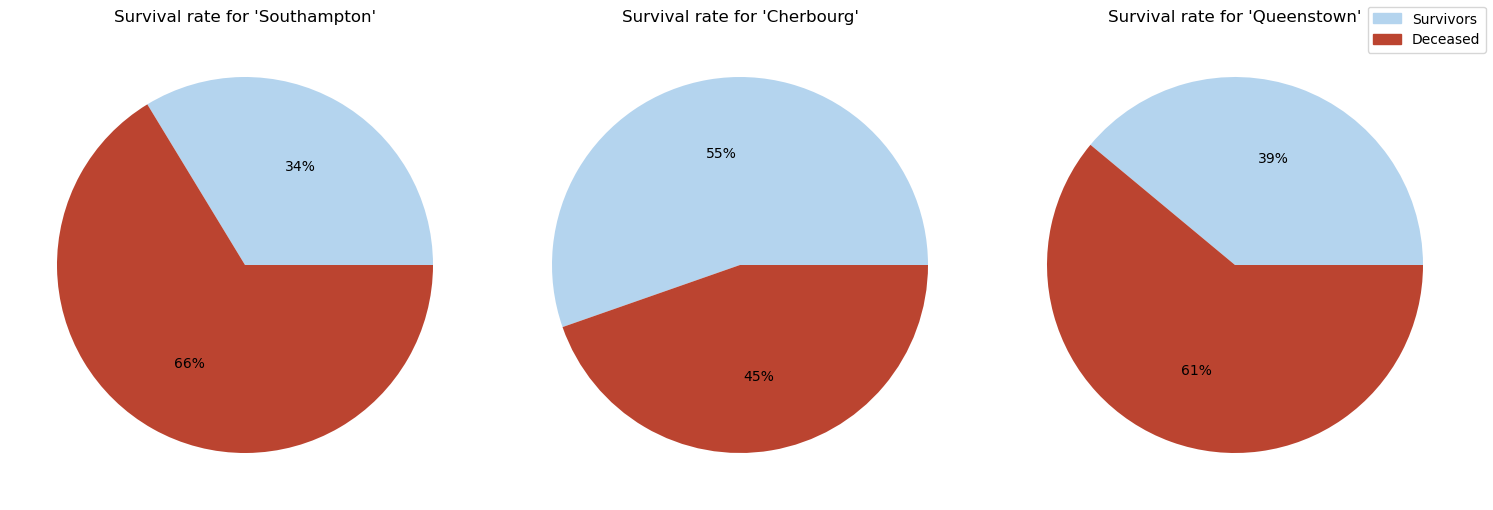

In [61]:
colors = ['#B4D4EE','#BB4430']
town_types = titanic["embark_town"].unique()

counts_per_who:list[list[int,int]]
counts_per_who = []

for town in town_types:
    survivors = len(titanic[(titanic["embark_town"] == town) & (titanic["survived"] == 1)])
    deceased = len(titanic[(titanic["embark_town"] == town) & (titanic["survived"] == 0)])
    counts = [survivors, deceased]
    counts_per_who.append(counts)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for i in range(len(town_types)-1):
    axes[i].pie(counts_per_who[i], colors=colors, autopct='%.0f%%')
    axes[i].set_title(f"Survival rate for '{town_types[i]}'")

survivor_patch = mpatches.Patch(color=colors[0], label="Survivors")
deceased_patch = mpatches.Patch(color=colors[1], label="Deceased")
fig.legend(handles=[survivor_patch, deceased_patch])  

plt.tight_layout()
plt.show()

We can see that guests who embarked from Cherbour had a higher survival rate. According to previous results, this could point towards either a different ratio of men to women and children or a different ratio of classes. Let's examine if that holds up by first checking the ratio of men to women and children.


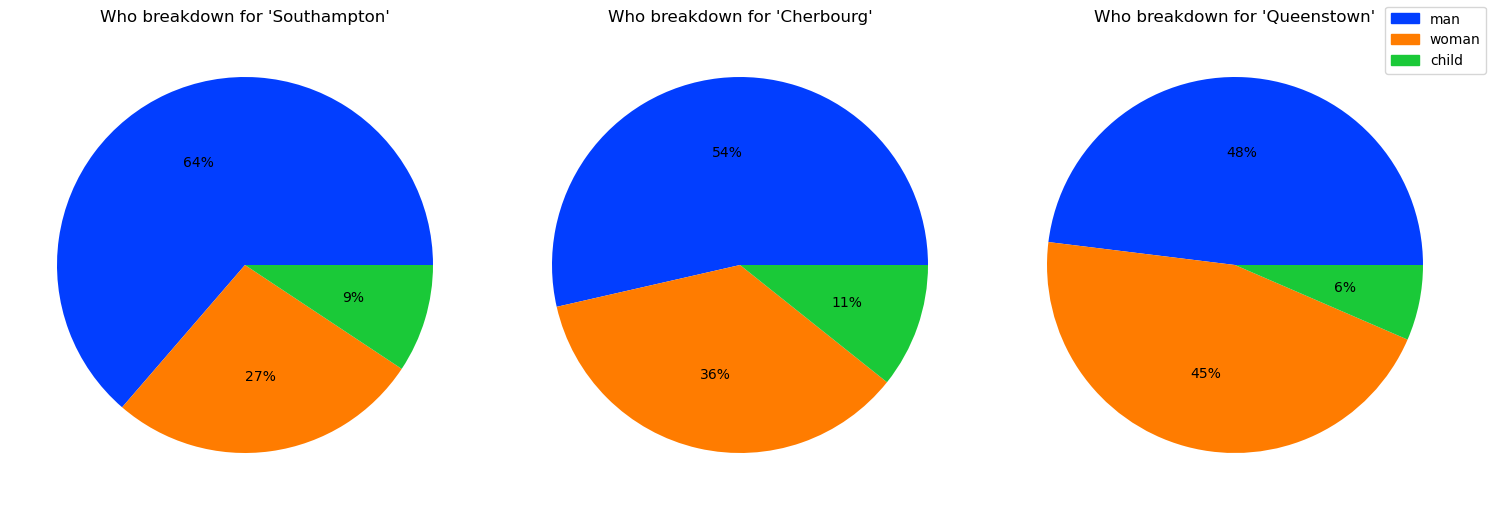

In [62]:
colors = sns.color_palette("bright")
town_types = titanic["embark_town"].unique()

counts_per_town:list[list[int,int,int]]
counts_per_town = []

for town in town_types:
    counts = []
    for who in ["man", "woman", "child"]:
        c = len(titanic[(titanic["embark_town"] == town) & (titanic["who"] == who)])
        counts.append(c)
    counts_per_town.append(counts)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for i in range(len(town_types)-1):
    axes[i].pie(counts_per_town[i], colors=colors, autopct='%.0f%%')
    axes[i].set_title(f"Who breakdown for '{town_types[i]}'")

c1 = mpatches.Patch(color=colors[0], label="man")
c2 = mpatches.Patch(color=colors[1], label="woman")
c3 = mpatches.Patch(color=colors[2], label="child")
fig.legend(handles=[c1, c2, c3])  

plt.tight_layout()
plt.show()


Looking at these pie charts we can see that passangers from Southampton are disproportionately men, explaining the difference in survival rates between Southampton and Cherbourg. But this does not explain the difference between Cherbourg and Queenstown as Queenstown has even smaller ratio of men/other in their passangers so now we look at class.

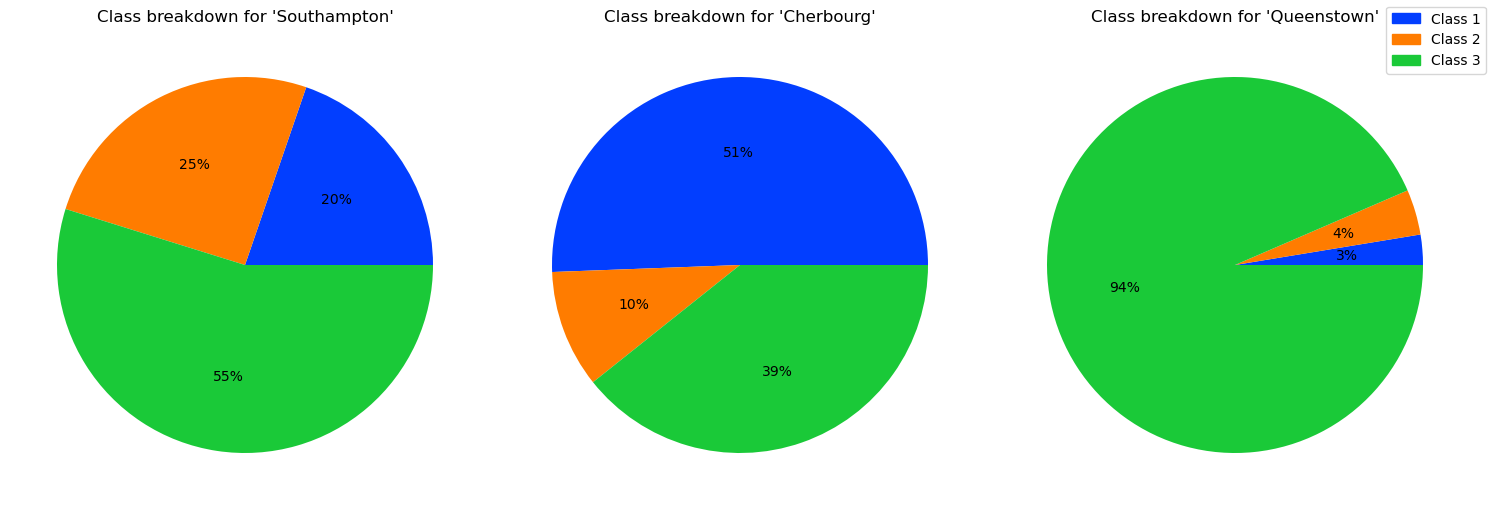

In [63]:
colors = sns.color_palette("bright")
town_types = titanic["embark_town"].unique()

counts_per_who:list[list[int,int]]
counts_per_who = []

for town in town_types:
    counts = []
    for class_ in ["First", "Second", "Third"]:
        c = len(titanic[(titanic["embark_town"] == town) & (titanic["class"] == class_)])
        counts.append(c)
    counts_per_who.append(counts)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for i in range(len(town_types)-1):
    axes[i].pie(counts_per_who[i], colors=colors, autopct='%.0f%%')
    axes[i].set_title(f"Class breakdown for '{town_types[i]}'")

c1 = mpatches.Patch(color=colors[0], label="Class 1")
c2 = mpatches.Patch(color=colors[1], label="Class 2")
c3 = mpatches.Patch(color=colors[2], label="Class 3")
fig.legend(handles=[c1, c2, c3])  

plt.tight_layout()
plt.show()


From these charts we see that passangers from Queenstown are almost entirely in Third Class while the percentage of  passangers from Cherbourg that are First Class is very high.
This supports our hypothesis as both Southampton and Queenstown have either the "women and children first" policy or class ratios dragging their survival rates down, whereas Cherbourg is either neutral, in the case of the policy, or being dragged up by them, in the case of class ratios.

### Note 2: The effects of decks on survival rate.

We decided that we wanted to investigate "Which deck is considered the most dangerous deck". So we made a graph that displays each deck and its amount of survivors and deceased. To preface, we noticed from glancing over the provided csv that many passengers do not have an assigned deck. This will be looked into later in this chapter. The following graphs apply strictly to those whose deck is recorded, not all passengers on the Titanic.

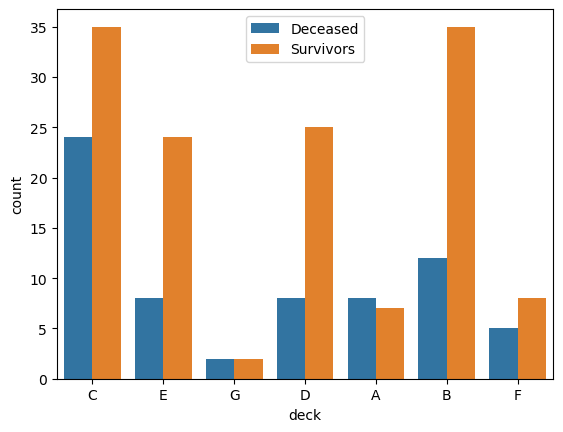

In [70]:
theplot = sns.countplot(data=titanic, x="deck", hue="survived")
plt.legend(labels=["Deceased", "Survivors"])
plt.show()

As we can see from the plot above, the C and A decks had the most passengers. Yet, despite having the same amount of survivors, deck C had almost double the amount of deceased. This can be due to many reasons such as: proximity to the crash, whether deck C housed mostly 3rd class passengers or maybe simply deck C had the most amount of passengers per lifeboat available to them and so more were left off them.  The plot with the lowest survival rate, is deck A with decks G and F trailing not far behind. Let's look into this a bit more. 

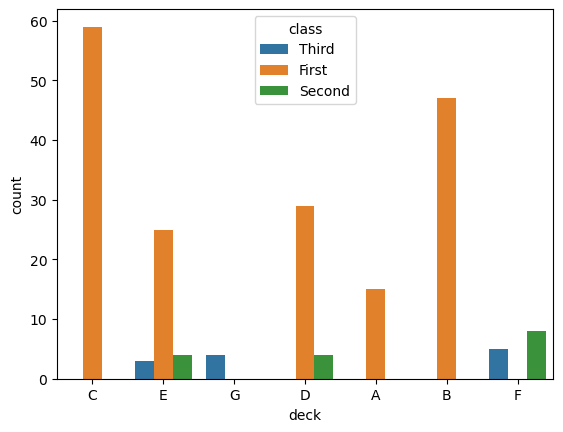

In [78]:
theplot = sns.countplot(data=titanic, x="deck", hue="class")
plt.show()

First checking how the classes are distributed on the decks we see that of all of the passengers whose deck was recorded most are in First Class. As we cannot figure out why it is this way with the data we have (just that it does not look random) we just have to try decipher what we can from it. Note: G and F have no First Class passengers, this could explain the low survival rate of those decks if our previous examinations of the data are correct. This does not explain the low survival rate of A at all though.

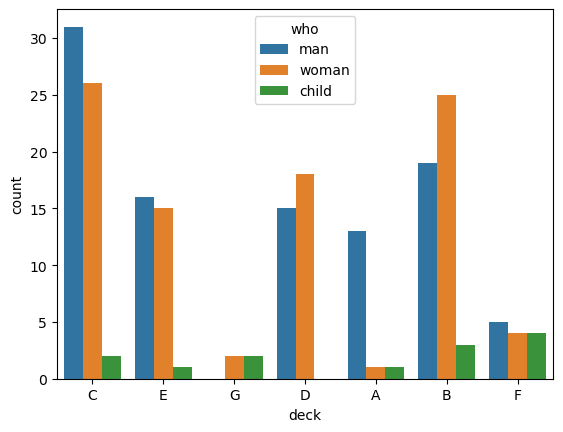

In [79]:
theplot = sns.countplot(data=titanic, x="deck", hue="who")
plt.show()

Here we get to see the potential reason for the low survival rate of deck A; It's passangers are overwhelmingly male. As we have seen from our past charts males tend to have a lower survival rate than women and children. Additionally, C has a larger ratio of men to women and children than B does, possibly explaining it's lower survival rate as well.